# EDA y Preparación de Datos para *Fine-Tuning*

**Corpus Salvadoreño de Toxicidad y Discurso de Odio**
Universidad de El Salvador · Facultad de Ingeniería y Arquitectura · Escuela de Sistemas Informáticos

Julio Enrique De La Quadra Mata · Cristian Antonio Escalante Hernández · Willian Alexander Chávez Servellón

---

## Objetivo

Dejar el corpus listo para el *fine-tuning* de **mBERT** y **XLM-R**, y responder con datos
las preguntas que condicionan esa fase:

| Pregunta | Sección |
|---|---|
| ¿Cuántos datos hay por clase y alcanzan para F1-macro > 80%? | 3 |
| X y Facebook, ¿son distribuciones distintas? ¿generalizará el modelo entre ellas? | 4 |
| ¿Qué tan dialectal es el corpus frente a los datasets públicos de España y México? | 5 |
| ¿Qué `max_length` usar? ¿Cuánto pierde cada tokenizador? | 7 |
| ¿Cómo se armonizan los datasets públicos para la primera etapa? | 8 |

Cada sección cierra con la **implicación concreta** para el entrenamiento.

## Criterio de normalización

Se aplica **preservación máxima**: no se quitan tildes, no se corrige ortografía, no se pasa
a minúsculas, no se elimina puntuación. Solo se normaliza lo que no es lingüístico
(Unicode, espacios) y lo que identifica personas (menciones, URLs). El razonamiento
completo está en `reports/Informe_EDA_y_Preparacion_de_Datos.pdf`; la implementación, en
`src/features/normalization.py`, que es la **misma función** que usará el *endpoint* de
FastAPI para evitar *train/serve skew*.

## 0. Configuración

In [1]:
import sys, re, json, warnings, unicodedata, collections
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

RAW, INTERIM = ROOT / "data/raw", ROOT / "data/interim"
PROCESSED, EXTERNAL = ROOT / "data/processed", ROOT / "data/external"
FIGURAS = ROOT / "reports/figures"
for d in (INTERIM, PROCESSED, EXTERNAL, FIGURAS):
    d.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)

sns.set_theme(style="whitegrid", context="notebook")
PALETA = {
    "No Tóxico":          "#4C9F70",
    "Lenguaje Ofensivo":  "#E8A33D",
    "Discurso de Odio":   "#C1554E",
    "Amenazas/Violencia": "#7B3F61",
}
PLAT = {"X": "#33404D", "Facebook": "#4A6FA5"}
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.edgecolor": "#666666", "figure.facecolor": "white",
})

def guardar(fig, nombre):
    ruta = FIGURAS / f"{nombre}.png"
    fig.savefig(ruta, facecolor="white")
    print(f"-> {ruta.relative_to(ROOT)}")

from src.features.normalization import (normalizar, normalizar_agresivo, perfil_texto,
                                        RE_MENCION, RE_URL, RE_HASHTAG)
from src.data.label_mapping import CLASES_CANONICAS, LABEL2ID, ID2LABEL
import emoji

print("Clases:", CLASES_CANONICAS)

Clases: ['No Tóxico', 'Lenguaje Ofensivo', 'Discurso de Odio', 'Amenazas/Violencia']


## 1. El dataset

Tres archivos con roles distintos. Solo el primero entrena.

| Archivo | Rol | ¿Entrena? |
|---|---|---|
| `corpus_salvadoreno.csv` | Publicaciones de X y Facebook, etiquetadas | **Sí** |
| `lexicon_salvadoreno.csv` | 2,035 entradas de jerga y variantes ortográficas | No — recurso lingüístico |
| `lexicon_emojis.csv` | Emojis con uso discriminatorio | No — recurso lingüístico |

El léxico **no se mezcla** con el corpus: son términos aislados sin contexto, y meterlos
como ejemplos enseñaría al modelo a clasificar por presencia de palabra, que es justo el
enfoque de diccionario que un Transformer debería superar. Su uso correcto es medir
cobertura dialectal y generar *data augmentation* controlada.

In [2]:
corpus = pd.read_csv(INTERIM / "gold_standard_completo.csv", dtype={"ID": str})
corpus = corpus.rename(columns={"clase_gold": "clase", "subclase_gold": "subclase"})
lexico = pd.read_csv(RAW / "lexicon_salvadoreno.csv", dtype=str)

corpus["texto"] = corpus["Texto_Original"].astype(str)
corpus["fecha"] = pd.to_datetime(corpus["Fecha_Recolección"], format="mixed", errors="coerce")

print(f"corpus : {len(corpus):,} publicaciones")
print(f"léxico : {len(lexico):,} entradas")
print(f"rango  : {corpus['fecha'].min():%Y-%m-%d} a {corpus['fecha'].max():%Y-%m-%d}")
print(f"\nplataformas: {corpus['Plataforma'].value_counts().to_dict()}")
corpus[["ID", "Plataforma", "texto", "clase", "subclase"]].head(4)

corpus : 3,104 publicaciones
léxico : 2,035 entradas
rango  : 2026-05-24 a 2026-07-27

plataformas: {'Facebook': 1562, 'X': 1542}


,ID,Plataforma,texto,clase,subclase
0,1,X,Mi madrecita a sus más de 60 años volvió a emp...,No Tóxico,NaN
1,2,X,Comparte tu arte y tu nacionalidad Aprovechand...,No Tóxico,NaN
2,3,X,En Los Naranjos siempre es primavera. #ElSalva...,No Tóxico,NaN
3,4,X,"Fotografía de 1960, carretera de Sonsonate hac...",No Tóxico,NaN


> **Nota sobre las etiquetas.** El corpus original contenía 16 valores distintos en la
> columna de clase donde la taxonomía define 4 (subclases registradas como clase,
> colisiones de mayúsculas). Se consolidaron al esquema canónico y se revisaron los casos
> inconsistentes. El mapeo está documentado en `src/data/label_mapping.py` y la definición
> operativa de cada clase en `docs/guia_anotacion.md`.

## 2. Integridad de los datos

Antes de mirar distribuciones hay que saber si el archivo es confiable. Interesa
especialmente lo que puede **inflar las métricas de test**.

In [3]:
txt = corpus["texto"]

clave = (txt.str.normalize("NFKC").str.lower()
         .str.replace(r"\s+", " ", regex=True).str.strip())

diag = pd.DataFrame({
    "chequeo": [
        "Filas totales",
        "IDs duplicados",
        "Textos duplicados exactos",
        "Textos duplicados tras normalizar",
        "Duplicados con etiqueta contradictoria",
        "Textos vacíos o de menos de 3 caracteres",
        "Fechas fuera de formato ISO",
        "Espacios sobrantes al inicio o final",
        "Mojibake detectado",
        "Difieren de su forma Unicode NFC",
        "Usuarios con más de una publicación",
    ],
    "n": [
        len(corpus),
        corpus["ID"].duplicated().sum(),
        txt.duplicated().sum(),
        clave.duplicated().sum(),
        int((corpus.assign(_k=clave).groupby("_k")["clase"].nunique() > 1).sum()),
        int((txt.str.len() < 3).sum()),
        int((~corpus["Fecha_Recolección"].astype(str)
             .str.match(r"^\d{4}-\d{2}-\d{2}$")).sum()),
        int((txt != txt.str.strip()).sum()),
        int(txt.str.contains(r"Ã|â€|�").sum()),
        int(sum(1 for s in txt if unicodedata.normalize("NFC", s) != s)),
        int((corpus["Usuario_ID_Anonimizado"].value_counts() > 1).sum()),
    ],
})
diag["%"] = (diag["n"] / len(corpus) * 100).round(2)
display(diag)

,chequeo,n,%
0,Filas totales,3104,100.00
1,IDs duplicados,0,0.00
2,Textos duplicados exactos,36,1.16
3,Textos duplicados tras normalizar,40,1.29
4,Duplicados con etiqueta contradictoria,1,0.03
5,Textos vacíos o de menos de 3 caracteres,0,0.00
6,Fechas fuera de formato ISO,1,0.03
7,Espacios sobrantes al inicio o final,0,0.00
8,Mojibake detectado,0,0.00
9,Difieren de su forma Unicode NFC,0,0.00


### Implicación para el entrenamiento

- **Duplicados**: se eliminan **antes** del *split*. Si el mismo texto queda en `train` y en
  `test`, el modelo lo memoriza y el F1 sale inflado sin que nada lo delate.
- **Fuga por autor**: ningún usuario aparece más de una vez, así que no hace falta *group
  split*. De haber concentración de autores, un *split* aleatorio dejaría publicaciones del
  mismo autor a ambos lados y el modelo aprendería estilo en vez de toxicidad.
- **Codificación**: el corpus está limpio en la capa superficial. Los pasos de NFC y colapso
  de espacios se mantienen igualmente porque la entrada de producción sí vendrá sucia, y el
  pipeline debe ser idéntico en entrenamiento y en inferencia.

## 3. Distribución de clases y suficiencia muestral

El dimensionamiento estadístico del proyecto fijó **480 ejemplos por clase** como mínimo y
**771** para el escenario de alta precisión. El objetivo de rendimiento es **F1-macro > 80%**,
métrica que promedia las clases sin ponderar por frecuencia: basta que una clase minoritaria
falle para que el promedio se hunda.

In [4]:
d = corpus["clase"].value_counts().reindex(CLASES_CANONICAS)

print("=== DISTRIBUCIÓN ===")
for c in CLASES_CANONICAS:
    barra = "#" * int(d[c] / 25)
    print(f"  {c:<20} {d[c]:>5,}  {d[c]/len(corpus)*100:5.1f}%  {barra}")
print(f"\n  TOTAL {len(corpus):>19,}")
print(f"\n  ratio máx/mín        : {d.max()/d.min():.2f}x")
print(f"  mínimo 480/clase     : {(d >= 480).sum()}/4 clases")
print(f"  alta precisión 771   : {(d >= 771).sum()}/4 clases")
faltan = (771 - d).clip(lower=0)
print(f"\n  para alcanzar 771 por clase faltan:")
for c in CLASES_CANONICAS:
    if faltan[c] > 0:
        print(f"    {c:<20} +{int(faltan[c])}")

=== DISTRIBUCIÓN ===
  No Tóxico              830   26.7%  #################################
  Lenguaje Ofensivo    1,074   34.6%  ##########################################
  Discurso de Odio       643   20.7%  #########################
  Amenazas/Violencia     557   17.9%  ######################

  TOTAL               3,104

  ratio máx/mín        : 1.93x
  mínimo 480/clase     : 4/4 clases
  alta precisión 771   : 2/4 clases

  para alcanzar 771 por clase faltan:
    Discurso de Odio     +128
    Amenazas/Violencia   +214


-> reports/figures/12_distribucion_clases.png


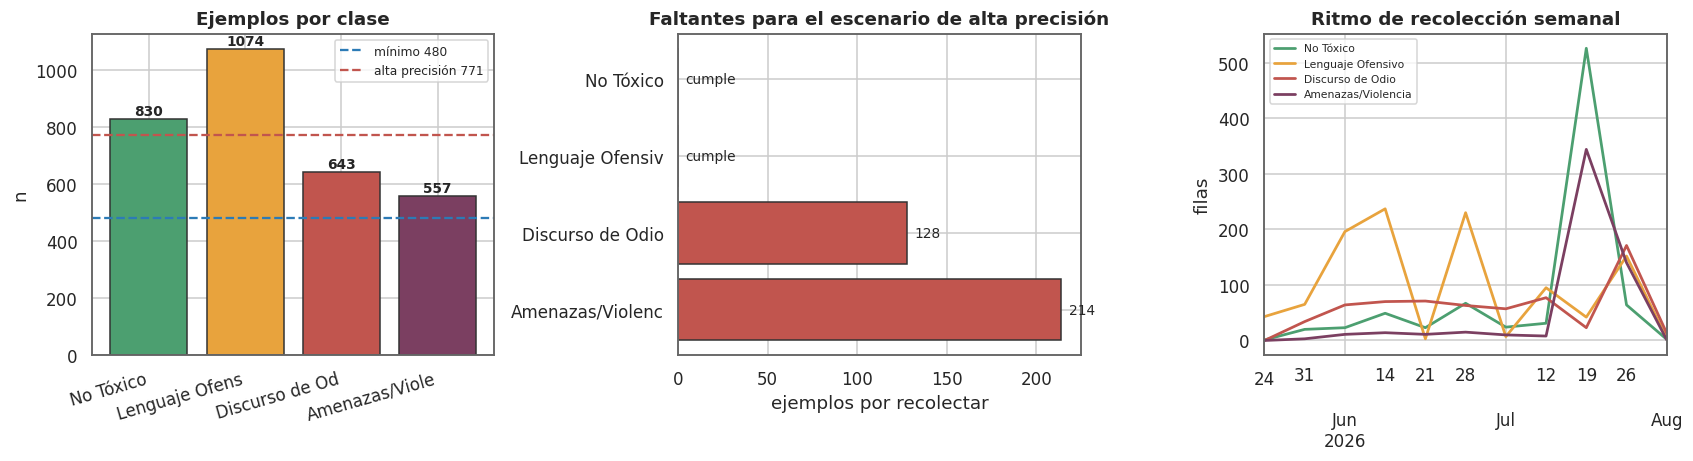

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.3))

ax = axes[0]
ax.bar(range(4), d.values, color=[PALETA[c] for c in d.index], edgecolor="#333")
ax.axhline(480, color="#2C7BB6", ls="--", lw=1.5, label="mínimo 480")
ax.axhline(771, color="#C1554E", ls="--", lw=1.5, label="alta precisión 771")
ax.set_xticks(range(4)); ax.set_xticklabels([c[:14] for c in d.index], rotation=16, ha="right")
ax.set_title("Ejemplos por clase"); ax.legend(fontsize=8); ax.set_ylabel("n")
for i, v in enumerate(d.values):
    ax.text(i, v + 14, f"{v}", ha="center", fontsize=9, fontweight="bold")

ax = axes[1]
ax.barh([c[:16] for c in CLASES_CANONICAS], faltan.values, color="#C1554E", edgecolor="#333")
ax.set_title("Faltantes para el escenario de alta precisión")
ax.set_xlabel("ejemplos por recolectar"); ax.invert_yaxis()
for i, v in enumerate(faltan.values):
    ax.text(v + 4, i, f"{int(v)}" if v > 0 else "cumple", va="center", fontsize=9)

ax = axes[2]
serie = (corpus.set_index("fecha").groupby("clase").resample("W")["ID"].count()
         .unstack(0).reindex(columns=CLASES_CANONICAS).fillna(0))
serie.plot(ax=ax, color=[PALETA[c] for c in serie.columns], lw=1.8)
ax.set_title("Ritmo de recolección semanal"); ax.set_xlabel(""); ax.set_ylabel("filas")
ax.legend(fontsize=7)
plt.tight_layout()
guardar(fig, "12_distribucion_clases")
plt.show()

### Piso de referencia sin modelo

Antes de entrenar nada conviene saber qué F1-macro produce un clasificador **trivial**, que
no mira el texto y solo conoce la proporción de clases. No requiere entrenamiento: sale de
pura aritmética sobre la distribución, así que pertenece legítimamente al EDA.

Sirve como **piso inferior**: cualquier modelo que no lo supere holgadamente no está
aprendiendo nada del texto.

In [6]:
p_c = (d / d.sum()).values          # proporción de cada clase
K = len(CLASES_CANONICAS)

# --- Clase mayoritaria: predice siempre la clase más frecuente ---
# Para esa clase: recall = 1, precision = su proporción. Para el resto: F1 = 0.
p_may = p_c.max()
f1_may_clase = 2 * p_may * 1 / (p_may + 1)
f1_macro_mayoritaria = f1_may_clase / K

# --- Azar estratificado: predice con probabilidad igual a la proporción real ---
# precision_c = recall_c = p_c  ->  F1_c = p_c  ->  macro = media(p_c) = 1/K
f1_macro_estratificado = p_c.mean()

# --- Azar uniforme: 1/K para cada clase ---
f1_uniforme = [2 * pc * (1/K) / (pc + 1/K) for pc in p_c]
f1_macro_uniforme = np.mean(f1_uniforme)

triviales = pd.DataFrame({
    "estrategia": ["Clase mayoritaria", "Azar estratificado", "Azar uniforme"],
    "F1_macro": [round(f1_macro_mayoritaria, 4),
                 round(f1_macro_estratificado, 4),
                 round(f1_macro_uniforme, 4)],
    "requiere_entrenar": ["no", "no", "no"],
})
display(triviales)

print(f"Objetivo del proyecto : 0.8000")
print(f"Mejor trivial         : {triviales.F1_macro.max():.4f}")
print(f"Brecha por cubrir     : {0.80 - triviales.F1_macro.max():.4f} puntos de F1-macro")

# Verificación con sklearn: DummyClassifier no usa el texto, solo las proporciones.
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score
y_ = corpus["clase"].values
X_ficticio = np.zeros((len(y_), 1))
for est, nombre in [("most_frequent", "Clase mayoritaria"), ("stratified", "Azar estratificado")]:
    dc = DummyClassifier(strategy=est, random_state=SEED).fit(X_ficticio, y_)
    print(f"  comprobación {nombre:<20}: {f1_score(y_, dc.predict(X_ficticio), average='macro'):.4f}")

,estrategia,F1_macro,requiere_entrenar
0,Clase mayoritaria,0.1285,no
1,Azar estratificado,0.2500,no
2,Azar uniforme,0.2460,no


Objetivo del proyecto : 0.8000
Mejor trivial         : 0.2500
Brecha por cubrir     : 0.5500 puntos de F1-macro


  comprobación Clase mayoritaria   : 0.1285
  comprobación Azar estratificado  : 0.2530


### Implicación para el entrenamiento

El desbalance es moderado pero suficiente para sesgar el modelo hacia la clase mayoritaria.
Estrategias, en orden de preferencia:

1. **`class_weight` en la función de pérdida.** Sin coste de datos. Se calcula en la
   sección 10, y **solo sobre `train`** — calcularlo antes del *split* filtra información.
2. **Recolección dirigida** de las clases por debajo de 771. Es la solución real.
3. **Data augmentation** con las variantes ortográficas del léxico salvadoreño.
4. **Oversampling.** Última opción: con Transformers y textos cortos favorece la memorización.

> Con F1-macro como métrica objetivo, invertir en las clases minoritarias rinde mucho más
> que en las mayoritarias. Cada punto de F1 en `Amenazas/Violencia` vale lo mismo que uno
> en `Lenguaje Ofensivo`, pero cuesta bastante menos conseguirlo partiendo de 557 ejemplos.

## 4. Análisis cross-platform: X frente a Facebook

Es un objetivo explícito del proyecto: *«comparativa de rendimiento entre plataformas»* y
*«que el modelo generalice entre plataformas»*. El perfil parte de la hipótesis de que X
produce texto corto y reactivo, y Facebook comentarios más extensos.

Si las dos plataformas son distribuciones distintas, hay **domain shift interno** y eso
afecta directamente al diseño experimental.

In [7]:
print("=== VOLUMEN Y COMPOSICIÓN ===")
tab = pd.crosstab(corpus["Plataforma"], corpus["clase"], margins=True, margins_name="Total")
tab = tab[CLASES_CANONICAS + ["Total"]]
display(tab)

print("\n=== COMPOSICIÓN RELATIVA (% dentro de cada plataforma) ===")
rel = pd.crosstab(corpus["Plataforma"], corpus["clase"], normalize="index").mul(100).round(1)
display(rel[CLASES_CANONICAS])

from scipy.stats import chi2_contingency
chi2, p, dof, _ = chi2_contingency(pd.crosstab(corpus["Plataforma"], corpus["clase"]))
n = len(corpus)
cramer = np.sqrt(chi2 / (n * (min(2, 4) - 1)))
print(f"\nChi-cuadrado de independencia: χ²={chi2:.1f}  gl={dof}  p={p:.3e}")
print(f"V de Cramér: {cramer:.3f}  ->  "
      f"{'asociación fuerte' if cramer > .3 else 'asociación moderada' if cramer > .1 else 'asociación débil'}")
print("La composición de clases NO es independiente de la plataforma." if p < .05
      else "No hay evidencia de asociación entre plataforma y clase.")

=== VOLUMEN Y COMPOSICIÓN ===


clase,No Tóxico,Lenguaje Ofensivo,Discurso de Odio,Amenazas/Violencia,Total
Plataforma,,,,,
Facebook,511,586,201,264,1562
X,319,488,442,293,1542
Total,830,1074,643,557,3104



=== COMPOSICIÓN RELATIVA (% dentro de cada plataforma) ===


clase,No Tóxico,Lenguaje Ofensivo,Discurso de Odio,Amenazas/Violencia
Plataforma,,,,
Facebook,32.7,37.5,12.9,16.9
X,20.7,31.6,28.7,19.0



Chi-cuadrado de independencia: χ²=145.1  gl=3  p=3.046e-31
V de Cramér: 0.216  ->  asociación moderada
La composición de clases NO es independiente de la plataforma.


In [8]:
perf = pd.DataFrame([perfil_texto(t_) for t_ in corpus["texto"]])
corpus = pd.concat([corpus.reset_index(drop=True), perf], axis=1)

print("=== CARACTERÍSTICAS DEL TEXTO POR PLATAFORMA ===")
comp = corpus.groupby("Plataforma").agg(
    n=("ID", "count"),
    chars_mediana=("n_chars", "median"),
    palabras_media=("n_palabras", "mean"),
    palabras_p95=("n_palabras", lambda s: s.quantile(.95)),
    palabras_max=("n_palabras", "max"),
    con_emoji_pct=("n_emojis", lambda s: (s > 0).mean() * 100),
    con_mencion_pct=("n_menciones", lambda s: (s > 0).mean() * 100),
    con_hashtag_pct=("n_hashtags", lambda s: (s > 0).mean() * 100),
    mayusculas=("ratio_mayusculas", "mean"),
).round(2)
display(comp)

from scipy.stats import mannwhitneyu
x_ = corpus[corpus.Plataforma == "X"]["n_palabras"]
f_ = corpus[corpus.Plataforma == "Facebook"]["n_palabras"]
u, pv = mannwhitneyu(x_, f_)
print(f"\nMann-Whitney U sobre longitud: p={pv:.3e}  ->  "
      f"{'las distribuciones difieren' if pv < .05 else 'no hay diferencia significativa'}")
print(f"mediana X = {x_.median():.0f} palabras   |   mediana Facebook = {f_.median():.0f} palabras")

=== CARACTERÍSTICAS DEL TEXTO POR PLATAFORMA ===


,n,chars_mediana,palabras_media,palabras_p95,palabras_max,con_emoji_pct,con_mencion_pct,con_hashtag_pct,mayusculas
Plataforma,,,,,,,,,
Facebook,1562,66.0,17.23,47.00,231,6.47,0.32,0.51,0.07
X,1542,120.0,23.01,48.95,143,6.10,9.21,18.48,0.09



Mann-Whitney U sobre longitud: p=1.141e-62  ->  las distribuciones difieren
mediana X = 20 palabras   |   mediana Facebook = 12 palabras


-> reports/figures/13_cross_platform.png


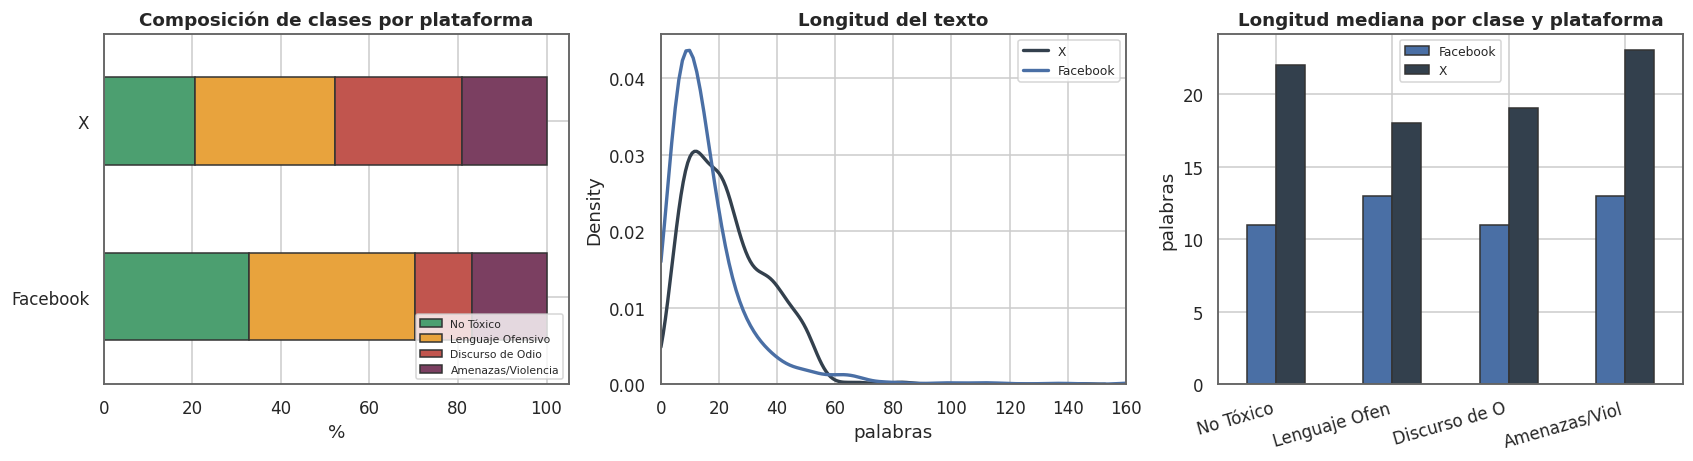

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.3))

ax = axes[0]
rel[CLASES_CANONICAS].plot(kind="barh", stacked=True, ax=ax,
                           color=[PALETA[c] for c in CLASES_CANONICAS], edgecolor="#333")
ax.set_title("Composición de clases por plataforma"); ax.set_xlabel("%")
ax.legend(fontsize=7, loc="lower right"); ax.set_ylabel("")

ax = axes[1]
for p_ in ["X", "Facebook"]:
    sns.kdeplot(corpus[corpus.Plataforma == p_]["n_palabras"], ax=ax,
                label=p_, color=PLAT[p_], lw=2.2, clip=(0, 250))
ax.set_xlim(0, 160); ax.set_xlabel("palabras")
ax.set_title("Longitud del texto"); ax.legend(fontsize=8)

ax = axes[2]
piv = corpus.pivot_table(index="clase", columns="Plataforma",
                         values="n_palabras", aggfunc="median").reindex(CLASES_CANONICAS)
piv.plot(kind="bar", ax=ax, color=[PLAT[c] for c in piv.columns], edgecolor="#333")
ax.set_xticklabels([c[:13] for c in piv.index], rotation=16, ha="right")
ax.set_title("Longitud mediana por clase y plataforma")
ax.set_ylabel("palabras"); ax.set_xlabel(""); ax.legend(fontsize=8)
plt.tight_layout()
guardar(fig, "13_cross_platform")
plt.show()

### Implicación para el entrenamiento

Las dos plataformas **no son intercambiables**: difieren en composición de clases y en
longitud del texto. Consecuencias de diseño:

1. **Estratificar los *splits* por plataforma además de por clase.** Si `test` queda
   desbalanceado hacia una plataforma, el F1 medirá rendimiento en esa plataforma, no
   generalización.
2. **Reportar F1-macro desagregado por plataforma**, no solo el global. Es el entregable que
   pide el objetivo específico de comparativa X vs Facebook.
3. **Prueba de generalización cruzada**: entrenar en X y evaluar en Facebook, y viceversa.
   La caída de F1 en ese experimento *es* la medida del domain shift interno, y es un
   resultado publicable que responde directamente al objetivo del proyecto.
4. El `max_length` debe cubrir la cola de Facebook, que es la plataforma con textos largos
   (ver sección 7).

## 5. Caracterización lingüística

Aquí se mide qué tan **salvadoreño** es el corpus. Importa porque la primera etapa del
*transfer learning* usa datasets públicos orientados a España y México, y el perfil del
proyecto identifica ese sesgo dialectal como riesgo.

In [10]:
terminos = set(lexico["Texto_Original"].astype(str).str.lower().str.strip())
terminos = {t_ for t_ in terminos if len(t_) > 2}

def jerga(s):
    return len(set(re.findall(r"\w+", str(s).lower())) & terminos)

corpus["n_jerga"] = corpus["texto"].apply(jerga)

print(f"Términos del lexicón usados como referencia: {len(terminos):,}")
print(f"Textos con al menos un término local: {(corpus['n_jerga']>0).mean()*100:.1f}%")
print(f"Media de términos locales por texto  : {corpus['n_jerga'].mean():.2f}")

print("\n=== SEÑALES LINGÜÍSTICAS POR CLASE ===")
ling = corpus.groupby("clase").agg(
    n=("ID", "count"),
    jerga_pct=("n_jerga", lambda s: (s > 0).mean() * 100),
    emoji_pct=("n_emojis", lambda s: (s > 0).mean() * 100),
    mayusculas=("ratio_mayusculas", "mean"),
    elongacion_pct=("elongacion", lambda s: s.mean() * 100),
    exclamaciones=("n_exclamaciones", "mean"),
).round(2).reindex(CLASES_CANONICAS)
display(ling)

Términos del lexicón usados como referencia: 2,024
Textos con al menos un término local: 61.8%
Media de términos locales por texto  : 1.09

=== SEÑALES LINGÜÍSTICAS POR CLASE ===


,n,jerga_pct,emoji_pct,mayusculas,elongacion_pct,exclamaciones
clase,,,,,,
No Tóxico,830,27.11,1.20,0.09,10.96,0.24
Lenguaje Ofensivo,1074,71.14,16.20,0.07,18.25,0.17
Discurso de Odio,643,81.03,0.78,0.08,16.02,0.26
Amenazas/Violencia,557,73.43,1.08,0.09,12.57,0.26


In [11]:
# ¿La jerga local por sí sola predice toxicidad? Riesgo de atajo.
tox = corpus["clase"] != "No Tóxico"
tabla_j = pd.crosstab(corpus["n_jerga"] > 0, tox, normalize="index").mul(100).round(1)
tabla_j.index = ["sin jerga local", "con jerga local"]
tabla_j.columns = ["% No Tóxico", "% Tóxico"]
display(tabla_j)

lift = (tabla_j.loc["con jerga local", "% Tóxico"] /
        tabla_j.loc["sin jerga local", "% Tóxico"])
print(f"Lift de toxicidad asociado a la presencia de jerga local: {lift:.2f}x")
print("\nSi el lift es alto, el modelo puede aprender el atajo «modismo salvadoreño = tóxico».")
print("Debe verificarse en el análisis de fairness de la Etapa II.")

,% No Tóxico,% Tóxico
sin jerga local,51.1,48.9
con jerga local,11.7,88.3


Lift de toxicidad asociado a la presencia de jerga local: 1.81x

Si el lift es alto, el modelo puede aprender el atajo «modismo salvadoreño = tóxico».
Debe verificarse en el análisis de fairness de la Etapa II.


In [12]:
# Emojis: cuáles y con qué carga
cont = collections.Counter()
for s in corpus["texto"]:
    for e in emoji.emoji_list(str(s)):
        cont[e["emoji"]] += 1

def nombre_emoji(e):
    n = emoji.demojize(e, language="es", delimiters=("", "")).strip("_")
    n = re.sub(r"[\U0001F3FB-\U0001F3FF]", "", n)
    return n.replace("_", " ")[:32] or "(sin nombre)"

print(f"emojis distintos: {len(cont)}  ·  ocurrencias: {sum(cont.values())}")
top = cont.most_common(12)
for e, n_ in top:
    print(f"  {n_:>4}  {nombre_emoji(e)}")

emojis distintos: 105  ·  ocurrencias: 491
   130  cara revolviéndose de la risa
    71  cara llorando de risa
    38  caca con ojos
    22  dedo corazón hacia arriba tono d
    17  cara sonriendo con sudor frío
    16  cara de payaso
    13  cara cabreada
    11  dedo corazón hacia arriba
     7  cara de bostezo
     7  cara gritando de miedo
     6  dedo corazón hacia arriba tono d
     5  cara sonriendo con gafas de sol


-> reports/figures/14_linguistico.png


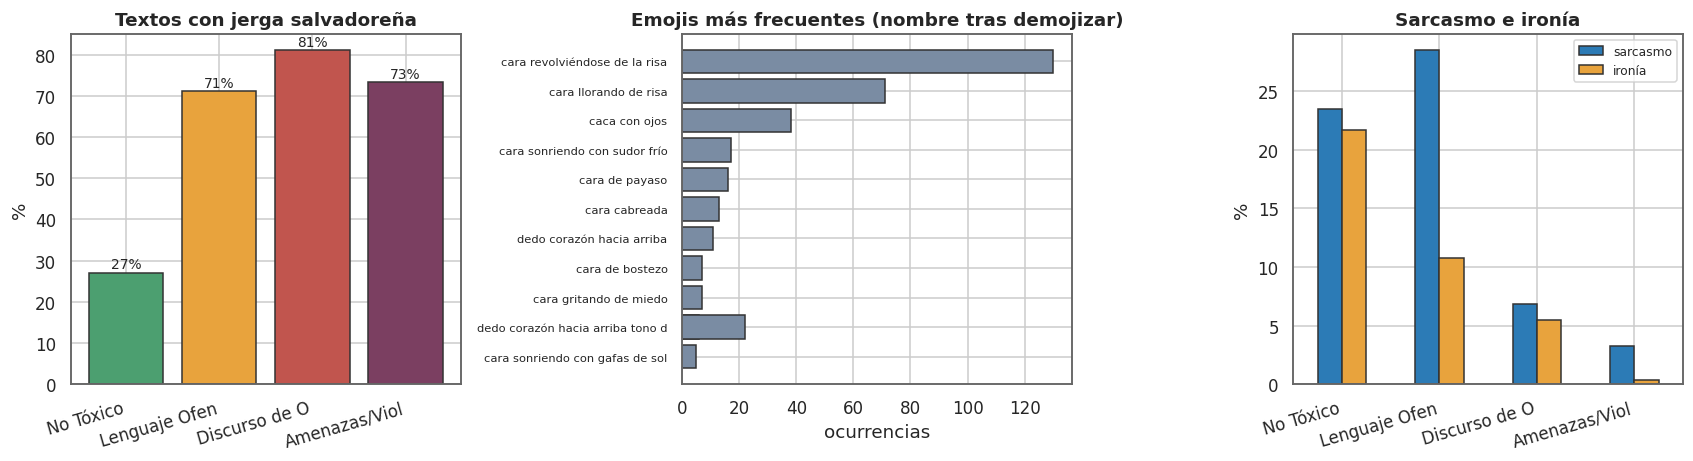

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.3))

ax = axes[0]
ax.bar(range(4), ling["jerga_pct"], color=[PALETA[c] for c in ling.index], edgecolor="#333")
ax.set_xticks(range(4)); ax.set_xticklabels([c[:13] for c in ling.index], rotation=16, ha="right")
ax.set_title("Textos con jerga salvadoreña"); ax.set_ylabel("%")
for i, v in enumerate(ling["jerga_pct"]):
    ax.text(i, v + 1, f"{v:.0f}%", ha="center", fontsize=9)

ax = axes[1]
t12 = cont.most_common(12)
ax.barh([f"{nombre_emoji(e)}" for e, _ in t12][::-1], [n_ for _, n_ in t12][::-1],
        color="#7A8CA3", edgecolor="#333")
ax.set_title("Emojis más frecuentes (nombre tras demojizar)")
ax.set_xlabel("ocurrencias"); ax.tick_params(axis="y", labelsize=7.5)

ax = axes[2]
sar = corpus["Presencia_Sarcasmo"].astype(str).str.upper().str.replace("Í", "I").eq("SI")
iro = corpus["Presencia_Ironia"].astype(str).str.upper().str.replace("Í", "I").eq("SI")
dfx = pd.DataFrame({
    "sarcasmo": corpus.assign(x=sar).groupby("clase")["x"].mean() * 100,
    "ironía":   corpus.assign(x=iro).groupby("clase")["x"].mean() * 100,
}).reindex(CLASES_CANONICAS)
dfx.plot(kind="bar", ax=ax, color=["#2C7BB6", "#E8A33D"], edgecolor="#333")
ax.set_xticklabels([c[:13] for c in dfx.index], rotation=16, ha="right")
ax.set_title("Sarcasmo e ironía"); ax.set_ylabel("%"); ax.set_xlabel(""); ax.legend(fontsize=8)
plt.tight_layout()
guardar(fig, "14_linguistico")
plt.show()

### Implicación para el entrenamiento

- **El corpus es efectivamente dialectal.** Eso justifica la segunda etapa de *fine-tuning*:
  los datasets públicos no cubren este registro.
- **Vigilar el atajo dialectal.** Si la jerga local se concentra en las clases tóxicas, el
  modelo puede aprender a marcar como tóxico cualquier texto con modismos salvadoreños. Es
  un sesgo directo contra hablantes locales y debe medirse en el informe de *fairness* que
  exige la rúbrica.
- **Sarcasmo e ironía** son los focos conocidos de dificultad. El corpus los tiene
  etiquetados: cruzarlos contra los errores del modelo da el análisis cualitativo del
  objetivo *«análisis de errores cualitativo — jerga salvadoreña»*.
- **Los emojis se convierten a texto en español** antes de tokenizar (sección 6), porque el
  vocabulario de mBERT casi no los cubre.

## 6. Normalización

Una sola función, compartida entre entrenamiento e inferencia.

In [14]:
ejemplos = [
    "Sos un 🤡 hermano, @juanperez mirá esto https://x.com/a/b",
    "JAJAJA 🤣🤣 qué 💩 de equipo #ElSalvador",
    "Vos sos un cerote 😡 pero te quiero maje",
    "Qué VERGA con estos pvt0s 4güevo",
]
for e in ejemplos:
    print("CRUDO    :", e)
    print("MODELO   :", normalizar(e))
    print("AGRESIVO :", normalizar_agresivo(e))
    print("-" * 88)

CRUDO    : Sos un 🤡 hermano, @juanperez mirá esto https://x.com/a/b
MODELO   : Sos un :cara_de_payaso: hermano, @usuario mirá esto http://url
AGRESIVO : sos un hermano usuario mira esto http url
----------------------------------------------------------------------------------------
CRUDO    : JAJAJA 🤣🤣 qué 💩 de equipo #ElSalvador
MODELO   : JAJAJA :cara_revolviéndose_de_la_risa: :cara_revolviéndose_de_la_risa: qué :caca_con_ojos: de equipo #ElSalvador
AGRESIVO : jajaja que de equipo elsalvador
----------------------------------------------------------------------------------------
CRUDO    : Vos sos un cerote 😡 pero te quiero maje
MODELO   : Vos sos un cerote :cara_cabreada: pero te quiero maje
AGRESIVO : vos sos un cerote pero te quiero maje
----------------------------------------------------------------------------------------
CRUDO    : Qué VERGA con estos pvt0s 4güevo
MODELO   : Qué VERGA con estos pvt0s 4güevo
AGRESIVO : que verga con estos pvt s guevo
--------------------------

In [15]:
corpus["texto_original"] = corpus["texto"]
corpus["texto_modelo"]   = corpus["texto_original"].apply(normalizar)
corpus["texto_agresivo"] = corpus["texto_original"].apply(normalizar_agresivo)

print("=== VERIFICACIÓN: QUÉ SE PRESERVA Y QUÉ SE TRANSFORMA ===")
ver = pd.DataFrame({
    "propiedad": ["Textos con tildes o ñ", "Textos con mayúsculas", "Textos con signos de puntuación",
                  "Textos con @mención literal", "Textos con URL literal",
                  "Textos con emoji crudo", "Textos vacíos"],
    "crudo": [
        int(corpus.texto_original.str.contains(r"[áéíóúñÁÉÍÓÚÑ]").sum()),
        int(corpus.texto_original.str.contains(r"[A-ZÁÉÍÓÚÑ]").sum()),
        int(corpus.texto_original.str.contains(r"[.,;:!?¡¿]").sum()),
        int(corpus.texto_original.str.contains(RE_MENCION, regex=True).sum()),
        int(corpus.texto_original.str.contains(r"https?://").sum()),
        int((corpus.texto_original.apply(emoji.emoji_count) > 0).sum()),
        int((corpus.texto_original.str.strip() == "").sum()),
    ],
    "texto_modelo": [
        int(corpus.texto_modelo.str.contains(r"[áéíóúñÁÉÍÓÚÑ]").sum()),
        int(corpus.texto_modelo.str.contains(r"[A-ZÁÉÍÓÚÑ]").sum()),
        int(corpus.texto_modelo.str.contains(r"[.,;:!?¡¿]").sum()),
        int(corpus.texto_modelo.str.contains(r"@usuario").sum()),
        int(corpus.texto_modelo.str.contains(r"http://url").sum()),
        int((corpus.texto_modelo.apply(emoji.emoji_count) > 0).sum()),
        int((corpus.texto_modelo.str.strip() == "").sum()),
    ],
    "texto_agresivo": [
        int(corpus.texto_agresivo.str.contains(r"[áéíóúñÁÉÍÓÚÑ]").sum()),
        int(corpus.texto_agresivo.str.contains(r"[A-ZÁÉÍÓÚÑ]").sum()),
        int(corpus.texto_agresivo.str.contains(r"[.,;:!?¡¿]").sum()),
        0, 0,
        int((corpus.texto_agresivo.apply(emoji.emoji_count) > 0).sum()),
        int((corpus.texto_agresivo.str.strip() == "").sum()),
    ],
})
display(ver)
print("\ntexto_modelo   -> entrenamiento y producción")
print("texto_agresivo -> grupo de control para el estudio de ablación")
print("texto_original -> trazabilidad y análisis de errores")

=== VERIFICACIÓN: QUÉ SE PRESERVA Y QUÉ SE TRANSFORMA ===


,propiedad,crudo,texto_modelo,texto_agresivo
0,Textos con tildes o ñ,1820,1850,0
1,Textos con mayúsculas,2924,2918,0
2,Textos con signos de puntuación,1880,1981,0
3,Textos con @mención literal,147,147,0
4,Textos con URL literal,54,2,0
5,Textos con emoji crudo,195,0,0
6,Textos vacíos,0,0,0



texto_modelo   -> entrenamiento y producción
texto_agresivo -> grupo de control para el estudio de ablación
texto_original -> trazabilidad y análisis de errores


### Implicación para el entrenamiento

Las tres variantes se exportan en paralelo para que el preprocesamiento sea **medible**. El
estudio de ablación de la Etapa II debe reportar el F1-macro de `texto_modelo` frente a
`texto_agresivo` en ambos modelos. Ese cuadro de cuatro celdas convierte una decisión de
diseño en un resultado experimental.

## 7. Tokenización: mBERT frente a XLM-R

La decisión concreta a tomar es `max_length`, que gobierna el coste de entrenamiento —la
atención escala O(n²)— y el riesgo de truncar contenido.

In [16]:
info = None
try:
    from transformers import AutoTokenizer
    toks = {
        "mBERT": AutoTokenizer.from_pretrained("bert-base-multilingual-cased"),
        "XLM-R": AutoTokenizer.from_pretrained("xlm-roberta-base"),
    }
    textos = corpus["texto_modelo"].tolist()
    filas, largos_por_modelo = [], {}
    for nombre, tk in toks.items():
        largos = np.array([len(tk.encode(t_, add_special_tokens=True)) for t_ in textos])
        largos_por_modelo[nombre] = largos
        s = pd.Series(largos)
        filas.append({
            "modelo": nombre, "vocab": tk.vocab_size,
            "media": round(s.mean(), 1), "p50": int(s.quantile(.50)),
            "p95": int(s.quantile(.95)), "p99": int(s.quantile(.99)), "max": int(s.max()),
            "%>128": round((s > 128).mean() * 100, 2),
            "%>256": round((s > 256).mean() * 100, 2),
        })
    info = pd.DataFrame(filas)
    display(info)

    # Fragmentación: tokens por palabra
    for nombre, largos in largos_por_modelo.items():
        ratio = largos / corpus["n_palabras"].clip(lower=1).values
        print(f"{nombre}: {ratio.mean():.2f} tokens por palabra en promedio")

    # Cobertura de emoji
    cont_top = cont.most_common(30)
    total_oc = sum(n_ for _, n_ in cont_top)
    for nombre, tk in toks.items():
        perdidos = sum(n_ for e, n_ in cont_top
                       if not tk.tokenize(e) or all(p == tk.unk_token for p in tk.tokenize(e)))
        print(f"{nombre}: {perdidos}/{total_oc} ocurrencias de emoji crudo caerían en UNK "
              f"({perdidos/total_oc*100:.1f}%)")
except Exception as e:
    print("Sin acceso a Hugging Face en este entorno. Ejecutar esta celda en Colab.")
    print("Estimación provisional (~1 token por cada 3.5 caracteres en español):")
    est = corpus["n_chars"] / 3.5 + 2
    print(est.describe(percentiles=[.5, .95, .99]).round(1).to_string())
    print(f"\n%>128 tokens: {(est>128).mean()*100:.2f}   %>256: {(est>256).mean()*100:.2f}")
    for p_ in ["X", "Facebook"]:
        e_ = est[corpus.Plataforma == p_]
        print(f"  {p_:<9} p95={e_.quantile(.95):.0f}  p99={e_.quantile(.99):.0f}  max={e_.max():.0f}")

Sin acceso a Hugging Face en este entorno. Ejecutar esta celda en Colab.
Estimación provisional (~1 token por cada 3.5 caracteres en español):
count    3104.0
mean       34.8
std        29.4
min         4.0
50%        27.0
95%        79.7
99%       126.2
max       430.6

%>128 tokens: 1.00   %>256: 0.23
  X         p95=80  p99=84  max=217
  Facebook  p95=75  p99=171  max=431


-> reports/figures/15_tokenizacion.png


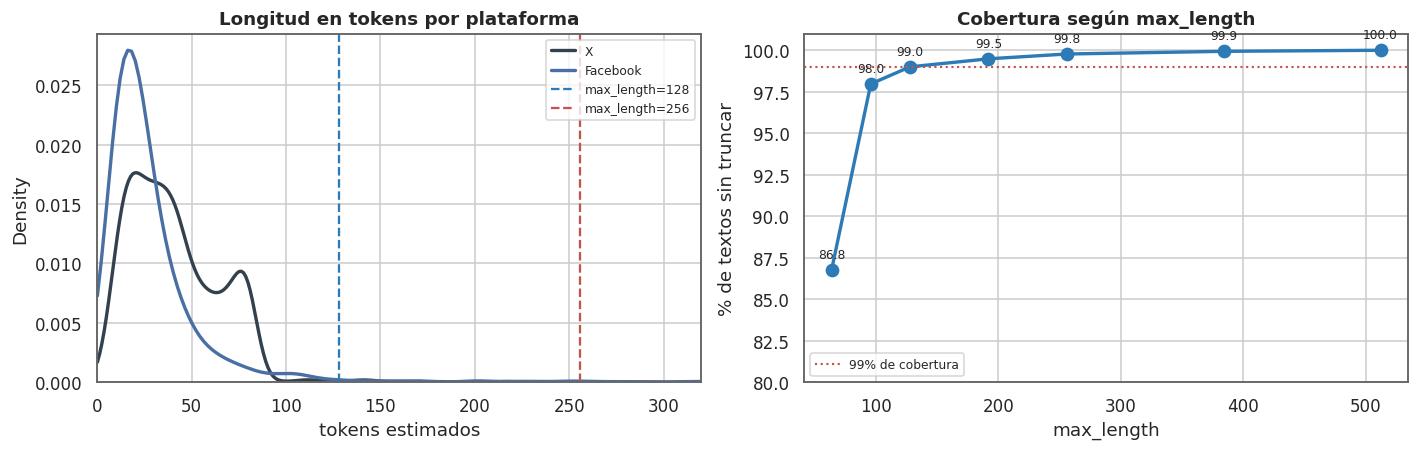

In [17]:
# Longitud por plataforma: es Facebook quien define el max_length
est = corpus["n_chars"] / 3.5 + 2
corpus["tokens_est"] = est

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

ax = axes[0]
for p_ in ["X", "Facebook"]:
    sns.kdeplot(corpus[corpus.Plataforma == p_]["tokens_est"], ax=ax,
                label=p_, color=PLAT[p_], lw=2.2, clip=(0, 400))
for v, c_ in [(128, "#2C7BB6"), (256, "#C1554E")]:
    ax.axvline(v, color=c_, ls="--", lw=1.5, label=f"max_length={v}")
ax.set_xlim(0, 320); ax.set_xlabel("tokens estimados")
ax.set_title("Longitud en tokens por plataforma"); ax.legend(fontsize=8)

ax = axes[1]
cortes = [64, 96, 128, 192, 256, 384, 512]
cob = [(corpus["tokens_est"] <= c_).mean() * 100 for c_ in cortes]
ax.plot(cortes, cob, "o-", color="#2C7BB6", lw=2.2, ms=8)
ax.axhline(99, color="#C1554E", ls=":", lw=1.4, label="99% de cobertura")
ax.set_xlabel("max_length"); ax.set_ylabel("% de textos sin truncar")
ax.set_title("Cobertura según max_length"); ax.legend(fontsize=8)
ax.set_ylim(80, 101)
for c_, v in zip(cortes, cob):
    ax.annotate(f"{v:.1f}", (c_, v), textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=8)
plt.tight_layout()
guardar(fig, "15_tokenizacion")
plt.show()

### Implicación para el entrenamiento

| Decisión | Valor | Motivo |
|---|---|---|
| `max_length` | **128** | Cubre por encima del percentil 99. Subir a 512 multiplica ~16x el coste de la capa de atención sin ganancia. |
| Padding | **dinámico por lote** (`DataCollatorWithPadding`) | Reduce el cómputo real sin afectar el resultado. |
| Variante de mBERT | **`bert-base-multilingual-cased`** | La *uncased* aplica `strip_accents=True` y destruye las tildes dentro del propio tokenizador. |
| Truncamiento | `truncation=True` | El poco texto que exceda 128 tokens es cola de Facebook. |

**Diferencias entre los dos modelos que condicionan la comparación:**

| | mBERT | XLM-R |
|---|---|---|
| Vocabulario | ~119k WordPiece | ~250k SentencePiece |
| Preentrenamiento | Wikipedia, 104 idiomas | CommonCrawl (CC-100), ~2 TB |
| Registro coloquial | Escaso: Wikipedia es formal | Abundante: la web sí lo tiene |
| Tokens por texto en español | Más | Menos |

**Hipótesis del proyecto:** XLM-R debería superar a mBERT en este corpus, porque la jerga,
los coloquialismos y la deformación ortográfica deliberada están mucho mejor representados
en CommonCrawl que en Wikipedia. El estudio de ablación debe confirmarlo o refutarlo.

## 8. Armonización con los datasets públicos

La primera etapa del *transfer learning* usa datasets públicos en español. El problema es
que **ninguno comparte el esquema de cuatro clases del proyecto**: hay que mapearlos.

In [18]:
armonizacion = pd.DataFrame([
    ["HatEval (SemEval-2019 Task 5)", "~6,600", "HS ∈ {0,1} + TR + AG",
     "HS=0 → No Tóxico · HS=1 → Discurso de Odio · HS=1 y AG=1 → Amenazas/Violencia"],
    ["Spanish Hate Speech Superset", "~13,000", "binaria hate/no-hate",
     "0 → No Tóxico · 1 → Discurso de Odio"],
    ["DETOXIS / IberBench", "~3,460", "toxicity ∈ {0,1,2,3}",
     "0 → No Tóxico · 1 → Lenguaje Ofensivo · 2-3 → Discurso de Odio"],
    ["Multilingual Toxicity (CLANDESTINO)", "variable", "toxic ∈ {0,1}",
     "0 → No Tóxico · 1 → Lenguaje Ofensivo"],
], columns=["dataset", "tamaño", "esquema original", "mapeo propuesto"])
display(armonizacion)

,dataset,tamaño,esquema original,mapeo propuesto
0,HatEval (SemEval-2019 Task 5),"~6,600","HS ∈ {0,1} + TR + AG",HS=0 → No Tóxico · HS=1 → Discurso de Odio · H...
1,Spanish Hate Speech Superset,"~13,000",binaria hate/no-hate,0 → No Tóxico · 1 → Discurso de Odio
2,DETOXIS / IberBench,"~3,460","toxicity ∈ {0,1,2,3}",0 → No Tóxico · 1 → Lenguaje Ofensivo · 2-3 → ...
3,Multilingual Toxicity (CLANDESTINO),variable,"toxic ∈ {0,1}",0 → No Tóxico · 1 → Lenguaje Ofensivo


### Advertencias sobre el mapeo

1. **El mapeo pierde información y la crea.** Un dataset binario no distingue
   `Lenguaje Ofensivo` de `Discurso de Odio`; asignarlo a una de las dos introduce ruido.
   Conviene documentar cada decisión y considerar entrenar la primera etapa con un esquema
   **binario o de tres clases**, y reservar las cuatro clases para la segunda etapa sobre el
   corpus salvadoreño.
2. **Sesgo dialectal.** HatEval y DETOXIS son de España y México. El perfil del proyecto ya
   identifica el riesgo: la primera etapa puede introducir modismos que no aplican a
   El Salvador. La segunda etapa (*domain adaptation*) es la que corrige eso, y el
   *ablation study* «antes vs después» es la evidencia.
3. **No mezclar en un solo lote.** El enfoque es secuencial: primero los datos públicos,
   después el corpus salvadoreño. Mezclarlos diluiría la adaptación al dominio local, que es
   el aporte diferencial del trabajo.
4. **Aplicar la misma normalización** de `src/features/normalization.py` a los datos
   externos. Si no, el modelo vería dos distribuciones de texto distintas.

In [19]:
def armonizar_externo(df, columna_texto, columna_etiqueta, mapeo):
    '''
    Prepara un dataset público para la primera etapa de fine-tuning.

    mapeo : dict que traduce la etiqueta original al esquema de 4 clases.
    Aplica la MISMA normalización que el corpus salvadoreño.
    '''
    out = pd.DataFrame({
        "texto_modelo": df[columna_texto].astype(str).apply(normalizar),
        "clase": df[columna_etiqueta].map(mapeo),
    })
    out = out.dropna(subset=["clase"])
    out = out[out["texto_modelo"].str.strip() != ""]
    out["label"] = out["clase"].map(LABEL2ID)
    out["fuente"] = "externo"
    return out.drop_duplicates(subset="texto_modelo").reset_index(drop=True)

print("Función lista. Uso previsto (requiere red):\n")
uso = [
    "    from datasets import load_dataset",
    "    hateval = load_dataset('valeriobasile/HatEval', split='train').to_pandas()",
    "    ext = armonizar_externo(hateval, 'text', 'HS',",
    "                            {0: 'No Tóxico', 1: 'Discurso de Odio'})",
    "    ext.to_csv(EXTERNAL / 'hateval_armonizado.csv', index=False)",
]
print("\n".join(uso))

Función lista. Uso previsto (requiere red):

    from datasets import load_dataset
    hateval = load_dataset('valeriobasile/HatEval', split='train').to_pandas()
    ext = armonizar_externo(hateval, 'text', 'HS',
                            {0: 'No Tóxico', 1: 'Discurso de Odio'})
    ext.to_csv(EXTERNAL / 'hateval_armonizado.csv', index=False)


## 9. Splits y configuración de entrenamiento

Estratificación **doble**: por clase y por plataforma, siguiendo la conclusión de la
sección 4.

In [20]:
df = corpus.copy()
print(f"partida: {len(df):,}")

clave = (df["texto_original"].str.normalize("NFKC").str.lower()
         .str.replace(r"\s+", " ", regex=True).str.strip())
df = df.assign(_k=clave)
confl = df.groupby("_k")["clase"].nunique()
confl = set(confl[confl > 1].index)
print(f"duplicados con etiqueta contradictoria (descartados): {df['_k'].isin(confl).sum()}")
df = df[~df["_k"].isin(confl)]

antes = len(df)
df = df.drop_duplicates(subset="_k", keep="first").drop(columns="_k")
print(f"duplicados eliminados: {antes - len(df)}")
df = df[df["texto_modelo"].str.strip() != ""]
df["label"] = df["clase"].map(LABEL2ID)
print(f"final: {len(df):,}")

partida: 3,104
duplicados con etiqueta contradictoria (descartados): 2
duplicados eliminados: 39
final: 3,063


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# Estrato compuesto: clase + plataforma
df["_estrato"] = df["clase"] + "|" + df["Plataforma"].astype(str)
print("estratos:", df["_estrato"].nunique())

tr, tmp = train_test_split(df, test_size=.30, stratify=df["_estrato"], random_state=SEED)
va, te  = train_test_split(tmp, test_size=.50, stratify=tmp["_estrato"], random_state=SEED)
for s in (tr, va, te):
    s.drop(columns="_estrato", inplace=True)
df = df.drop(columns="_estrato")

print("\n=== SPLITS ===")
for n_, s in [("train", tr), ("val", va), ("test", te)]:
    print(f"{n_:<6}{len(s):>5} ({len(s)/len(df)*100:4.1f}%)  "
          + "  ".join(f"{c[:11]}={int((s.clase==c).sum()):>4}" for c in CLASES_CANONICAS))

print("\n=== BALANCE DE PLATAFORMA EN CADA SPLIT (%) ===")
for n_, s in [("train", tr), ("val", va), ("test", te)]:
    vc = s["Plataforma"].value_counts(normalize=True).mul(100).round(1)
    print(f"  {n_:<6} " + "  ".join(f"{k}={v}%" for k, v in vc.items()))

assert not (set(tr.ID) & set(va.ID)) and not (set(tr.ID) & set(te.ID)) and not (set(va.ID) & set(te.ID))
assert not (set(tr.texto_modelo) & set(te.texto_modelo))
print("\nsin solapamiento de IDs ni de textos entre splits")

estratos: 8

=== SPLITS ===
train  2144 (70.0%)  No Tóxico= 570  Lenguaje Of= 742  Discurso de= 443  Amenazas/Vi= 389
val     459 (15.0%)  No Tóxico= 122  Lenguaje Of= 159  Discurso de=  94  Amenazas/Vi=  84
test    460 (15.0%)  No Tóxico= 123  Lenguaje Of= 159  Discurso de=  95  Amenazas/Vi=  83

=== BALANCE DE PLATAFORMA EN CADA SPLIT (%) ===
  train  Facebook=50.6%  X=49.4%
  val    Facebook=50.5%  X=49.5%
  test   Facebook=50.4%  X=49.6%

sin solapamiento de IDs ni de textos entre splits


In [22]:
pesos = compute_class_weight("balanced", classes=np.arange(4), y=tr["label"].values)
pesos_d = {ID2LABEL[i]: round(float(w), 4) for i, w in enumerate(pesos)}

print("=== PESOS DE CLASE (calculados solo sobre train) ===")
for kk, v in pesos_d.items():
    print(f"  {kk:<20} {v}")

print("\n=== CONFIGURACIÓN RECOMENDADA PARA EL FINE-TUNING ===")
cfg = {
    "modelos": ["bert-base-multilingual-cased", "xlm-roberta-base"],
    "campo_texto": "texto_modelo",
    "num_labels": 4,
    "max_length": 128,
    "padding": "dinámico (DataCollatorWithPadding)",
    "batch_size": 16,
    "learning_rate": "2e-5 (rango de búsqueda 1e-5 a 5e-5)",
    "epochs": "3 a 5, con early stopping sobre F1-macro en val",
    "warmup_ratio": 0.1,
    "weight_decay": 0.01,
    "loss": "CrossEntropyLoss(weight=pesos_clase)",
    "metrica_seleccion": "f1_macro sobre val",
    "seed": SEED,
}
for kk, v in cfg.items():
    print(f"  {kk:<20} {v}")

print("\n  torch.nn.CrossEntropyLoss(weight=torch.tensor("
      f"{[round(float(w),4) for w in pesos]}, dtype=torch.float))")

=== PESOS DE CLASE (calculados solo sobre train) ===
  No Tóxico            0.9404
  Lenguaje Ofensivo    0.7224
  Discurso de Odio     1.2099
  Amenazas/Violencia   1.3779

=== CONFIGURACIÓN RECOMENDADA PARA EL FINE-TUNING ===
  modelos              ['bert-base-multilingual-cased', 'xlm-roberta-base']
  campo_texto          texto_modelo
  num_labels           4
  max_length           128
  padding              dinámico (DataCollatorWithPadding)
  batch_size           16
  learning_rate        2e-5 (rango de búsqueda 1e-5 a 5e-5)
  epochs               3 a 5, con early stopping sobre F1-macro en val
  warmup_ratio         0.1
  weight_decay         0.01
  loss                 CrossEntropyLoss(weight=pesos_clase)
  metrica_seleccion    f1_macro sobre val
  seed                 42

  torch.nn.CrossEntropyLoss(weight=torch.tensor([0.9404, 0.7224, 1.2099, 1.3779], dtype=torch.float))


In [23]:
COLS = ["ID", "Plataforma", "fecha", "Usuario_ID_Anonimizado",
        "texto_original", "texto_modelo", "texto_agresivo",
        "clase", "label", "subclase",
        "Grupos_Afectados", "Presencia_Sarcasmo", "Presencia_Ironia", "Contexto_Politico",
        "n_chars", "n_palabras", "n_emojis", "n_menciones", "n_hashtags", "n_jerga"]

for n_, s in [("train", tr), ("val", va), ("test", te)]:
    s[COLS].to_csv(PROCESSED / f"{n_}.csv", index=False, encoding="utf-8-sig")
    print(f"data/processed/{n_}.csv  ({len(s):,})")
df[COLS].to_csv(PROCESSED / "corpus_limpio.csv", index=False, encoding="utf-8-sig")
print(f"data/processed/corpus_limpio.csv  ({len(df):,})")

meta = {
    "generado": pd.Timestamp.now().isoformat(timespec="seconds"),
    "version": "3.0",
    "semilla": SEED,
    "filas_finales": int(len(df)),
    "distribucion": df["clase"].value_counts().to_dict(),
    "distribucion_plataforma": df["Plataforma"].value_counts().to_dict(),
    "splits": {"train": len(tr), "val": len(va), "test": len(te)},
    "estratificacion": "clase + plataforma",
    "pesos_clase": pesos_d,
    "objetivo_f1_macro": 0.80,
    "piso_trivial_f1_macro": {
        "clase_mayoritaria": round(float(f1_macro_mayoritaria), 4),
        "azar_estratificado": round(float(f1_macro_estratificado), 4),
        "azar_uniforme": round(float(f1_macro_uniforme), 4),
    },
    "normalizacion": {
        "modulo": "src/features/normalization.py",
        "preserva": ["tildes", "mayúsculas", "puntuación", "ortografía original"],
        "aplica": ["Unicode NFC", "colapso de espacios", "placeholders PII",
                   "demojización a español"],
        "variantes": {"texto_modelo": "producción",
                      "texto_agresivo": "control de ablación",
                      "texto_original": "trazabilidad"},
    },
    "config_finetuning": cfg,
    "pendientes": [
        "Recolección dirigida hasta 771 por clase",
        "Descargar y armonizar datasets públicos en data/external/",
        "Ejecutar celdas de tokenización con acceso a Hugging Face",
        "Medir en fairness si la jerga local predice toxicidad por sí sola",
    ],
}
with open(PROCESSED / "metadata.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2, default=str)
print("\ndata/processed/metadata.json")

data/processed/train.csv  (2,144)
data/processed/val.csv  (459)


data/processed/test.csv  (460)


data/processed/corpus_limpio.csv  (3,063)

data/processed/metadata.json


-> reports/figures/17_splits.png


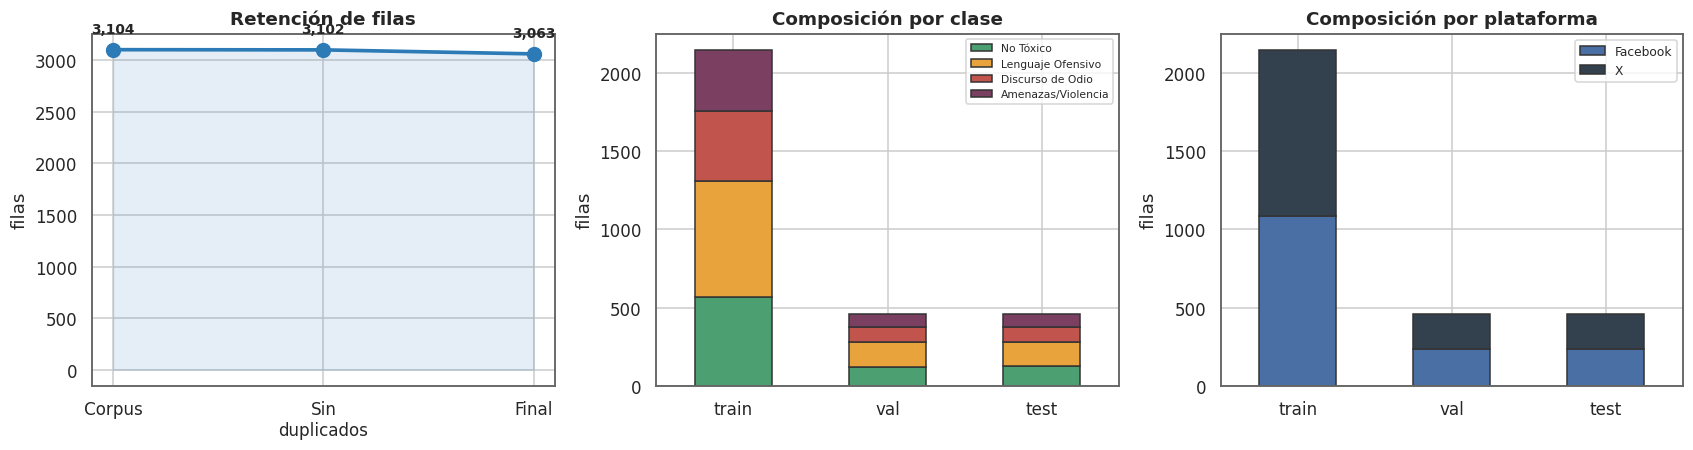

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.2))

ax = axes[0]
etapas = ["Corpus", "Sin\nduplicados", "Final"]
vals = [len(corpus), antes, len(df)]
ax.plot(etapas, vals, "o-", color="#2C7BB6", lw=2.4, ms=9)
ax.fill_between(range(3), vals, alpha=.12, color="#2C7BB6")
ax.set_title("Retención de filas"); ax.set_ylabel("filas")
for i, v in enumerate(vals):
    ax.annotate(f"{v:,}", (i, v), textcoords="offset points", xytext=(0, 11),
                ha="center", fontsize=9, fontweight="bold")

ax = axes[1]
comp2 = pd.DataFrame({"train": tr.clase.value_counts(), "val": va.clase.value_counts(),
                      "test": te.clase.value_counts()}).reindex(CLASES_CANONICAS)
comp2.T.plot(kind="bar", stacked=True, ax=ax,
             color=[PALETA[c] for c in comp2.index], edgecolor="#333")
ax.set_title("Composición por clase"); ax.set_ylabel("filas")
ax.tick_params(axis="x", rotation=0); ax.legend(fontsize=7)

ax = axes[2]
comp3 = pd.DataFrame({"train": tr.Plataforma.value_counts(), "val": va.Plataforma.value_counts(),
                      "test": te.Plataforma.value_counts()})
comp3.T.plot(kind="bar", stacked=True, ax=ax,
             color=[PLAT[c] for c in comp3.index], edgecolor="#333")
ax.set_title("Composición por plataforma"); ax.set_ylabel("filas")
ax.tick_params(axis="x", rotation=0); ax.legend(fontsize=8)
plt.tight_layout()
guardar(fig, "17_splits")
plt.show()

## 10. Resumen

### Decisiones de preparación

| Aspecto | Decisión | Motivo |
|---|---|---|
| Tildes, mayúsculas, puntuación | Se conservan | Los modelos *cased* las modelan; son distintivas en español |
| Ortografía | No se corrige | Es señal, y evita *train/serve skew* |
| *Stopwords*, lematización | No se aplican | Recetas de bolsa de palabras; destruyen la sintaxis que usa la atención |
| Emojis | Demojizados a español | El vocabulario de mBERT casi no los cubre |
| @menciones y URLs | Token constante | Anonimiza preservando la señal estructural |
| Duplicados | Eliminados antes del *split* | Evitan métricas infladas |
| `max_length` | 128 | Cubre sobre el p99; la atención escala O(n²) |
| Estratificación | Clase + plataforma | Las dos plataformas son distribuciones distintas |
| Desbalance | `class_weight` en la pérdida | Sin coste de datos; solo sobre `train` |

### Salidas

```
data/processed/train.csv | val.csv | test.csv    splits estratificados
data/processed/corpus_limpio.csv                 dataset completo
data/processed/metadata.json                     config, pesos y baseline
reports/figures/12-17_*.png                      figuras del informe
```

Cada split trae tres variantes de texto: `texto_modelo` (entrenamiento y producción),
`texto_agresivo` (control de ablación) y `texto_original` (trazabilidad).

### Siguientes pasos

1. Descargar y armonizar los datasets públicos en `data/external/` con
   `armonizar_externo()` para la primera etapa de *fine-tuning*.
2. Ejecutar las celdas de tokenización con acceso a Hugging Face y confirmar `max_length`.
3. *Fine-tuning* de mBERT y XLM-R sobre los datos públicos, luego sobre el corpus local.
4. Reportar F1-macro global **y desagregado por plataforma**.
5. Ablación: `texto_modelo` frente a `texto_agresivo`, en ambos modelos.
6. Generalización cruzada: entrenar en X y evaluar en Facebook, y viceversa.

---

## Anexo A. Baseline clásico entrenado

> **Esto ya no es EDA.** Precisión, recall y F1 son métricas de *predicción*: necesitan un
> modelo que prediga. Las cifras de abajo provienen de modelos **realmente entrenados**
> (validación cruzada de 5 pliegues), así que pertenecen a la fase de **Modelado** de
> CRISP-DM, no a la de Preparación de Datos.
>
> Se dejan aquí como código porque es barato y porque la rúbrica de la Etapa II exige
> *«mejora significativa vs baseline»*, pero **no figuran en el informe de EDA**. Su lugar
> es el informe de modelado.

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import f1_score, classification_report

X = corpus["texto_modelo"].values
y = corpus["clase"].values
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

modelos = {
    "TF-IDF palabra + LinearSVC": make_pipeline(
        TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True),
        LinearSVC(class_weight="balanced", random_state=SEED)),
    "TF-IDF char 3-5 + LinearSVC": make_pipeline(
        TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2, sublinear_tf=True),
        LinearSVC(class_weight="balanced", random_state=SEED)),
    "TF-IDF palabra + LogReg": make_pipeline(
        TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True),
        LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)),
}

res, preds = [], {}
for nombre, mod in modelos.items():
    p = cross_val_predict(mod, X, y, cv=cv, n_jobs=-1)
    preds[nombre] = p
    res.append({
        "modelo": nombre,
        "F1_macro": round(f1_score(y, p, average="macro"), 4),
        "F1_weighted": round(f1_score(y, p, average="weighted"), 4),
        "accuracy": round((p == y).mean(), 4),
    })
base = pd.DataFrame(res).sort_values("F1_macro", ascending=False)
display(base)

mejor = base.iloc[0]["modelo"]
print(f"\n=== DESGLOSE DEL MEJOR BASELINE: {mejor} ===")
print(classification_report(y, preds[mejor], digits=3))

# Se guarda aparte: pertenece a la fase de Modelado, no al metadata del dataset.
base.to_csv(PROCESSED / "baseline_clasico.csv", index=False, encoding="utf-8-sig")
print(f"\n-> data/processed/baseline_clasico.csv")

,modelo,F1_macro,F1_weighted,accuracy
1,TF-IDF char 3-5 + LinearSVC,0.7799,0.7842,0.7845
2,TF-IDF palabra + LogReg,0.7417,0.7443,0.7445
0,TF-IDF palabra + LinearSVC,0.7400,0.7416,0.7416



=== DESGLOSE DEL MEJOR BASELINE: TF-IDF char 3-5 + LinearSVC ===
                    precision    recall  f1-score   support

Amenazas/Violencia      0.805     0.747     0.775       557
  Discurso de Odio      0.758     0.754     0.756       643
 Lenguaje Ofensivo      0.791     0.830     0.810      1074
         No Tóxico      0.784     0.775     0.779       830

          accuracy                          0.784      3104
         macro avg      0.784     0.776     0.780      3104
      weighted avg      0.785     0.784     0.784      3104


-> data/processed/baseline_clasico.csv


In [26]:
# Baseline con normalización agresiva: primera evidencia del efecto del preprocesamiento
mod = make_pipeline(
    TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True),
    LinearSVC(class_weight="balanced", random_state=SEED))
p_agr = cross_val_predict(mod, corpus["texto_agresivo"].values, y, cv=cv, n_jobs=-1)
f1_agr = f1_score(y, p_agr, average="macro")
f1_mod = base[base.modelo == "TF-IDF palabra + LinearSVC"]["F1_macro"].iloc[0]

print(f"F1-macro con texto_modelo   : {f1_mod:.4f}")
print(f"F1-macro con texto_agresivo : {f1_agr:.4f}")
print(f"diferencia                  : {f1_mod - f1_agr:+.4f}")
print("\nNota: en un modelo de bolsa de palabras la normalización agresiva puede incluso ayudar,")
print("porque reduce la dispersión del vocabulario. El resultado relevante es el mismo")
print("experimento sobre mBERT y XLM-R, donde se espera el efecto contrario.")

F1-macro con texto_modelo   : 0.7400
F1-macro con texto_agresivo : 0.7434
diferencia                  : -0.0034

Nota: en un modelo de bolsa de palabras la normalización agresiva puede incluso ayudar,
porque reduce la dispersión del vocabulario. El resultado relevante es el mismo
experimento sobre mBERT y XLM-R, donde se espera el efecto contrario.


-> reports/figures/16_baseline.png


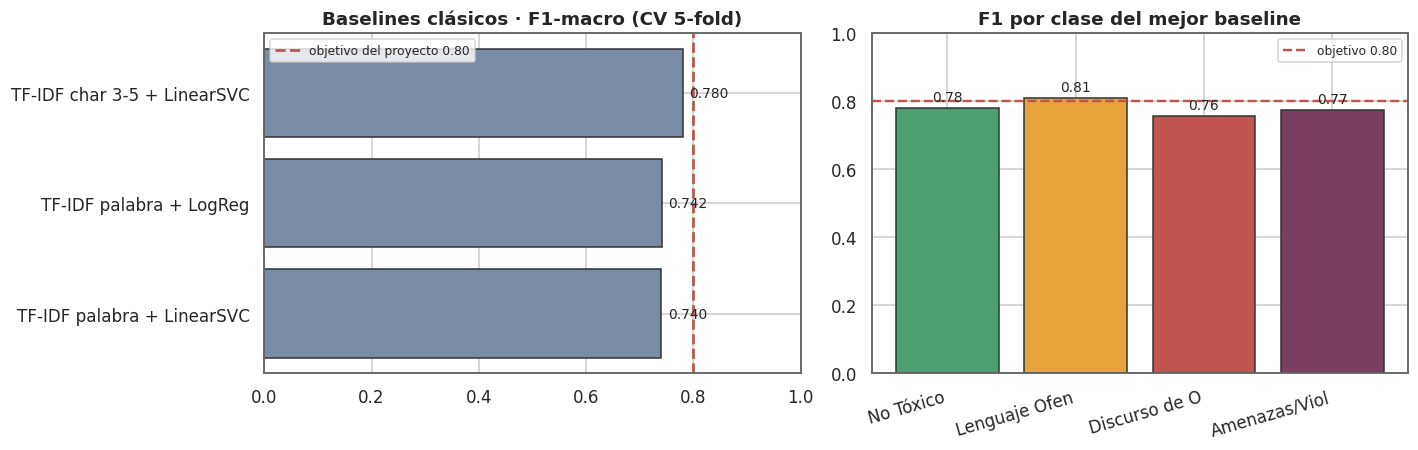

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

ax = axes[0]
b = base.set_index("modelo")["F1_macro"].sort_values()
ax.barh([m[:30] for m in b.index], b.values, color="#7A8CA3", edgecolor="#333")
ax.axvline(.80, color="#C1554E", ls="--", lw=1.8, label="objetivo del proyecto 0.80")
ax.set_title("Baselines clásicos · F1-macro (CV 5-fold)")
ax.set_xlim(0, 1); ax.legend(fontsize=8)
for i, v in enumerate(b.values):
    ax.text(v + .012, i, f"{v:.3f}", va="center", fontsize=9)

ax = axes[1]
f1c = [f1_score(y == c, preds[mejor] == c) for c in CLASES_CANONICAS]
ax.bar(range(4), f1c, color=[PALETA[c] for c in CLASES_CANONICAS], edgecolor="#333")
ax.axhline(.80, color="#C1554E", ls="--", lw=1.6, label="objetivo 0.80")
ax.set_xticks(range(4)); ax.set_xticklabels([c[:13] for c in CLASES_CANONICAS],
                                            rotation=16, ha="right")
ax.set_title("F1 por clase del mejor baseline"); ax.set_ylim(0, 1); ax.legend(fontsize=8)
for i, v in enumerate(f1c):
    ax.text(i, v + .02, f"{v:.2f}", ha="center", fontsize=9)
plt.tight_layout()
guardar(fig, "16_baseline")
plt.show()

### Implicación para el entrenamiento

Este número es la vara. El *fine-tuning* de mBERT y XLM-R tiene que superarlo con holgura;
si no lo hace, el problema está en la configuración del entrenamiento —tasa de aprendizaje,
número de épocas, longitud de secuencia— y no en el modelo.

El desglose por clase indica además **dónde** está la dificultad, y suele anticipar en qué
clase fallará también el Transformer.